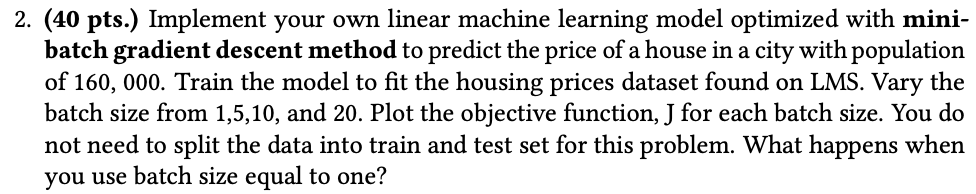

In [21]:
import pandas as pd
import numpy as np

housing_prices = pd.read_csv("/content/work/housing_prices.txt", header=None)
# rename columns
housing_prices.columns = ["Population_in_10k", "Price_in_10k"]
print(housing_prices)

X = np.asarray(housing_prices.Population_in_10k)
y = np.asarray(housing_prices.Price_in_10k)

    Population_in_10k  Price_in_10k
0              6.1101      17.59200
1              5.5277       9.13020
2              8.5186      13.66200
3              7.0032      11.85400
4              5.8598       6.82330
..                ...           ...
92             5.8707       7.20290
93             5.3054       1.98690
94             8.2934       0.14454
95            13.3940       9.05510
96             5.4369       0.61705

[97 rows x 2 columns]


Batch size=1, Predicted house price for population of 160k is $159144.1571391441
Batch size=5, Predicted house price for population of 160k is $137523.16562040956
Batch size=10, Predicted house price for population of 160k is $130857.50560217573
Batch size=20, Predicted house price for population of 160k is $127529.04268291719


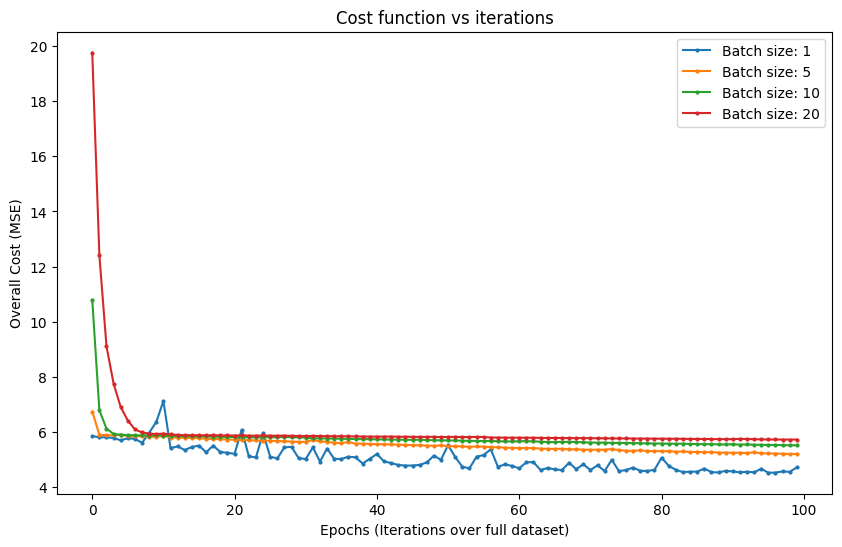

In [23]:
class LinearRegression:
  def __init__(self, batch_size=1, learning_rate=0.001, n_iters=100):
    self.batch_size = batch_size
    self.lr = learning_rate
    self.n_iters = n_iters
    self.weight = 0.0
    self.bias = 0.0
    self.cost_history = []

  def forward(self, X):
    return self.weight * X + self.bias

  def _mse(self, y, y_pred):
    return np.dot((y - y_pred), (y - y_pred).T) * 0.5 / len(y)

  def backward(self, X, y, y_pred):
    error = y_pred - y

    # Calculate scalar gradients for weight and bias
    dw = np.mean(error * X)
    db = np.mean(error)

    # Update parameters
    self.weight -= self.lr * dw
    self.bias -= self.lr * db

  def fit(self, X, y):
    num_samples = len(X)
    for _ in range(self.n_iters):
      # Generate randomized indices to shuffle X and y together at each epoch
      indices = np.arange(num_samples)
      np.random.shuffle(indices)
      X_shuffled = X[indices]
      y_shuffled = y[indices]

      n_batches = num_samples // self.batch_size
      for batch in range(n_batches):
        X_batch = X_shuffled[batch*self.batch_size:(batch + 1)*self.batch_size]
        y_batch = y_shuffled[batch*self.batch_size:(batch + 1)*self.batch_size]
        y_pred = self.forward(X_batch)
        self.backward(X_batch, y_batch, y_pred)

      # Record the cost over the entire dataset at the end of each epoch
      y_all_pred = self.forward(X)
      epoch_cost = self._mse(y, y_all_pred)
      self.cost_history.append(float(epoch_cost))

cost_histories = {}
for batch_size in (1, 5, 10, 20):
  # Using a fixed seed for reproducible shuffling comparison
  np.random.seed(42)
  model = LinearRegression(batch_size=batch_size)
  model.fit(X, y)
  cost_histories[batch_size] = model.cost_history
  prediction = model.forward(160_000/10_000)
  print(f"Batch size={batch_size}, Predicted house price for population of 160k is ${prediction * 10_000}")

# Plot all cost histories
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.title("Cost function vs iterations (with Shuffled Mini-Batches)")
for batch_size, cost_history in cost_histories.items():
  plt.plot(cost_history, marker='o', markersize=2, label=f'Batch size: {batch_size}')
plt.title("Cost function vs iterations")
plt.xlabel("Epochs (Iterations over full dataset)")
plt.ylabel("Overall Cost (MSE)")
plt.legend()
plt.show()

With a batch size of 1, the model updates its weights based on the gradient of one single randomly chosen sample at a time.
If the randomly selected sample is an outlier, the update step can push the global parameters $w$ and $b$ far away from the optimal solution.
